# Transformers from Scratch

This notebook is an attempt at implementing the Transformer architecture from scratch as described in the paper "Attention Is All You Need" by Google.

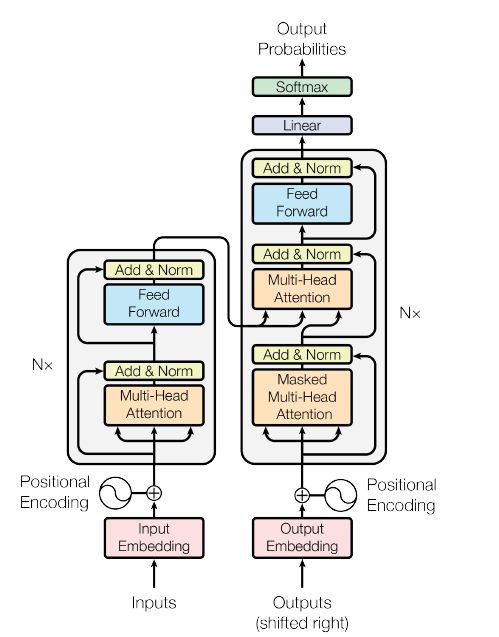
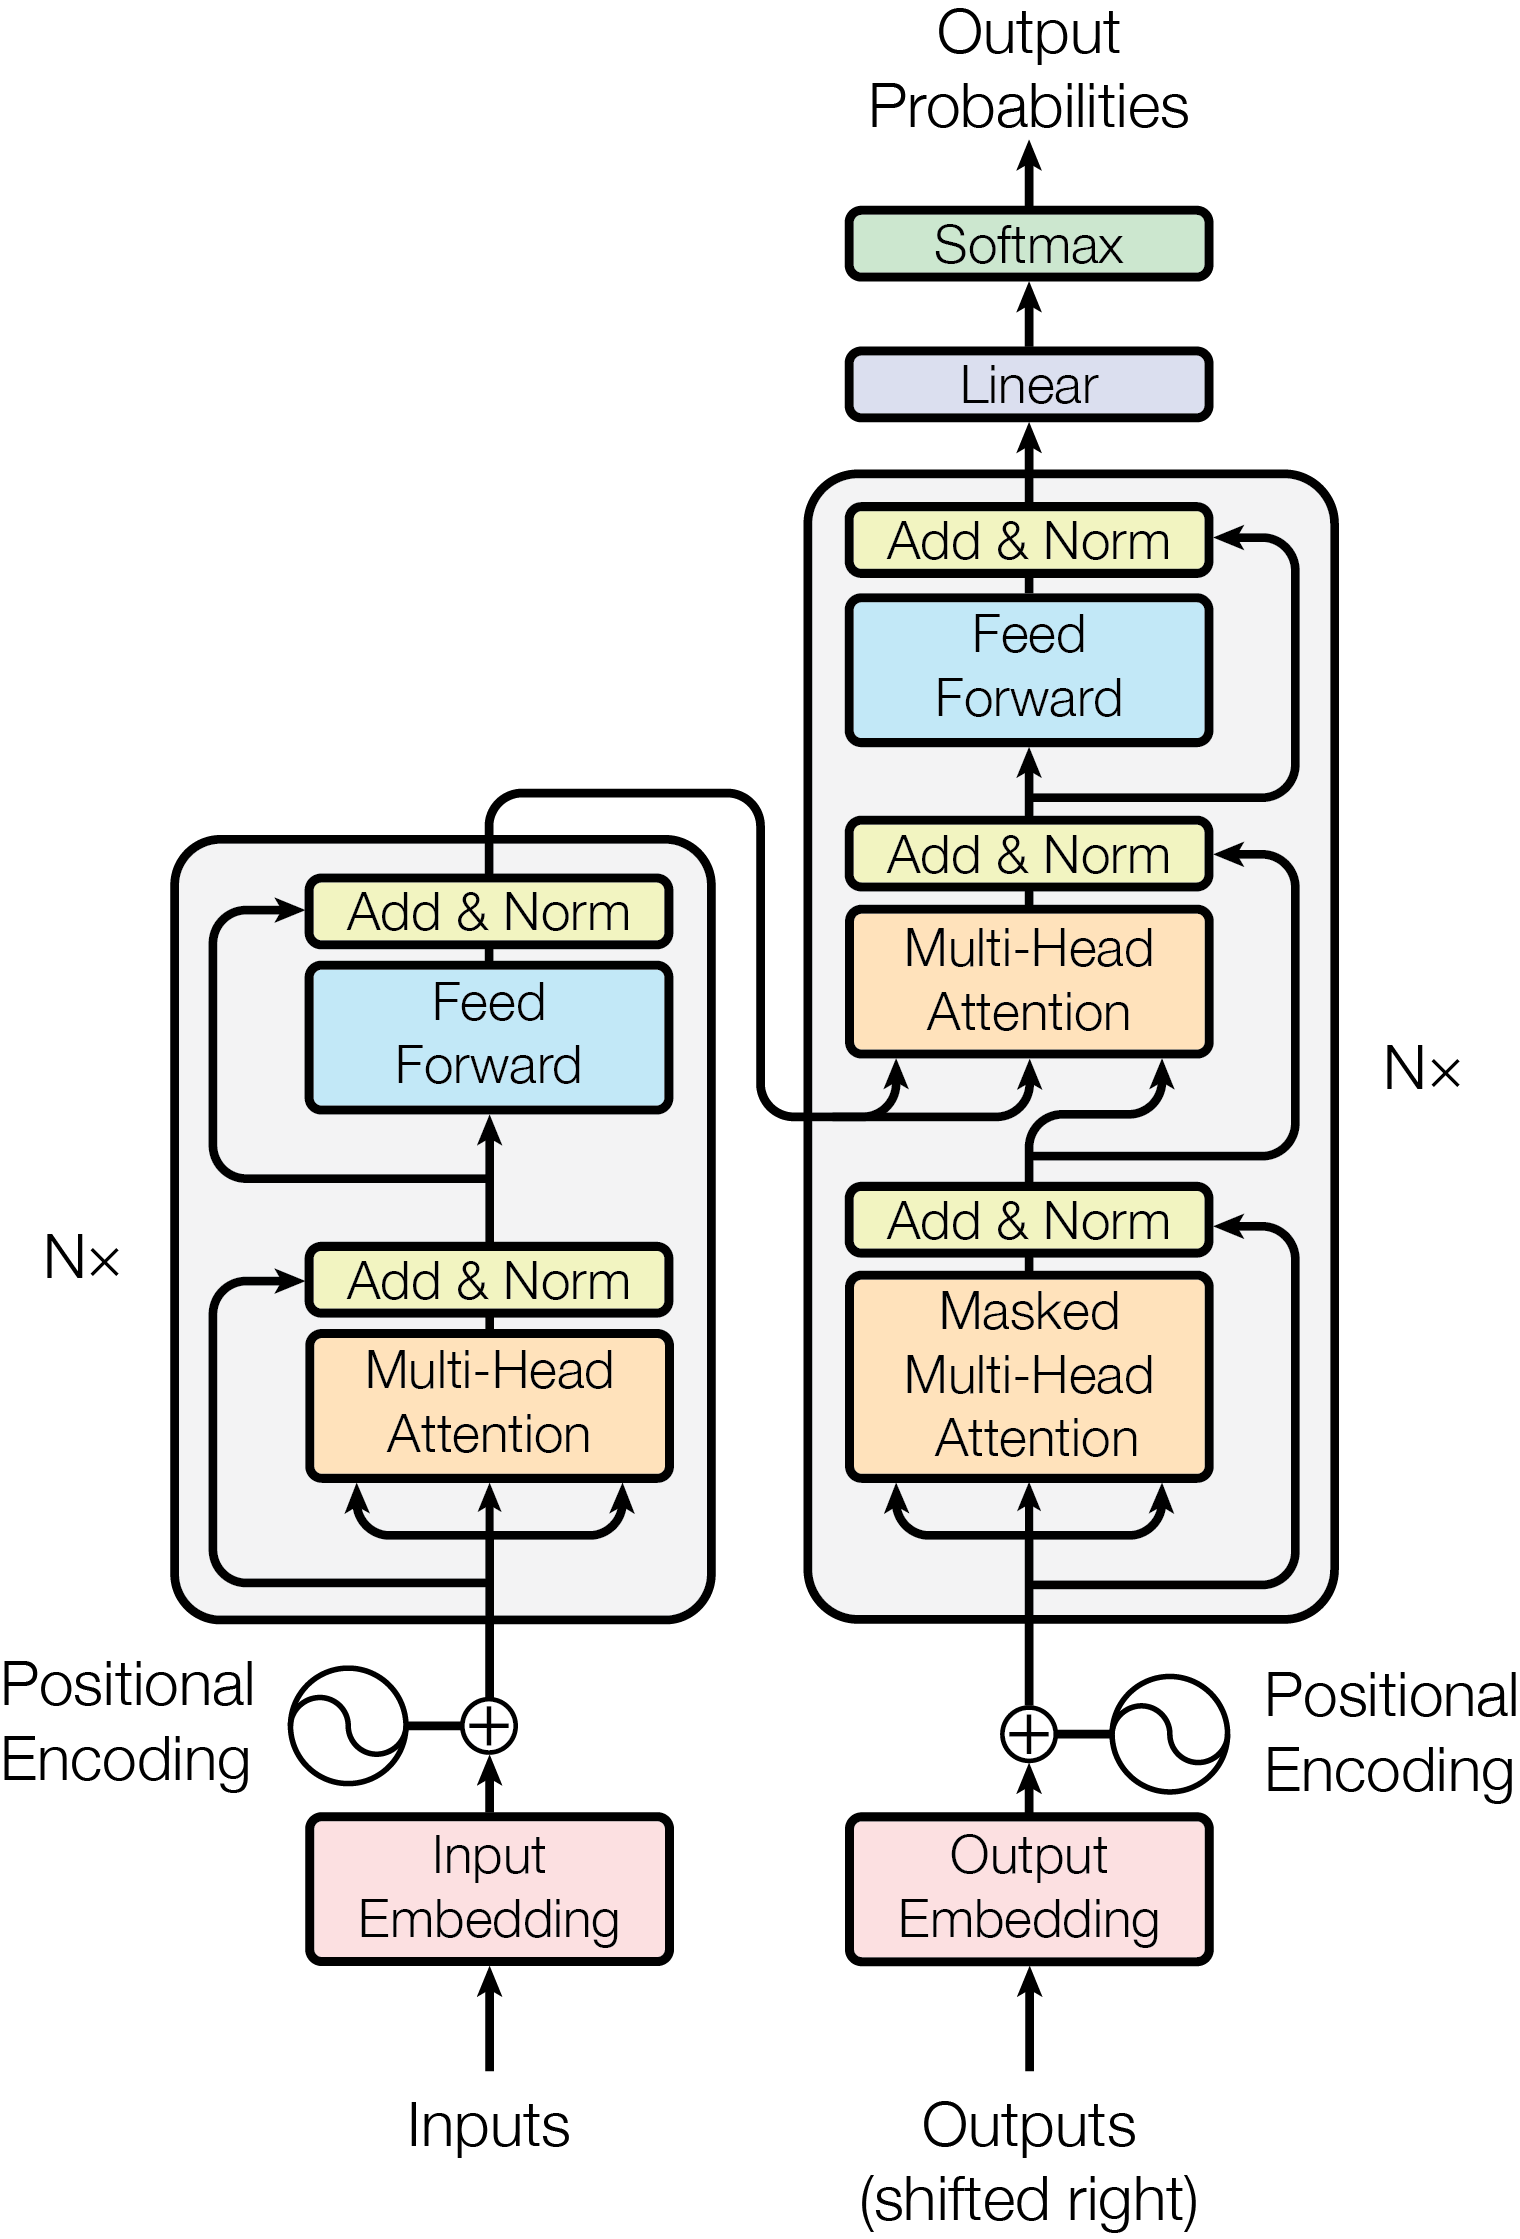

In [53]:
import torch
import torch.nn as nn
import math
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader, Dataset
import torch.nn.utils.rnn as rnn_utils
import torch.optim as optim
from tqdm import tqdm

# Encoder

## Input Embeddings

We convert the input tokens into vectors of dimension $d_\text{model}$, then we multiply each embedding by $\sqrt{d_\text{model}}$.

In [2]:
class InputEmbedding(nn.Module):
  
  def __init__(self, d_model, vocab_size):
    super().__init__()
    self.d_model = d_model
    self.vocab_size = vocab_size
    self.embedding = nn.Embedding(vocab_size, d_model)
    
  def forward(self, X):
    return self.embedding(X) * math.sqrt(self.d_model)

## Positional Encodings

The input embeddings are summed up with their positional encodings, which encode information about the relative and absolute positions of the tokens in the sequence, using sine and cosine as follows:

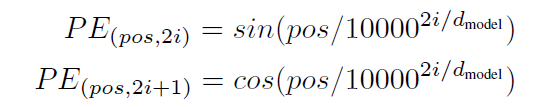

Positional encodings are not learnable, we will therefore detach them from the dynamic computation graph

We will then add them up with input embeddings, then apply dropout

In [3]:
class PositionalEncoding(nn.Module):
  
  def __init__(self, d_model, seq_length, dropout_rate=0.1):
    super().__init__()
    self.d_model = d_model
    self.seq_length = seq_length
    self.dropout = nn.Dropout(dropout_rate)
    
    positional_encoding = torch.zeros(seq_length, d_model)
    position = torch.arange(0, seq_length, dtype=torch.float).unsqueeze(1)
    
    # To assure numerical stability, we will apply log and exp on the denominator
    
    denominator = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000)))
    
    # We then apply sine to the even positions, and cosine to the odd positions
    
    positional_encoding[:, ::2] = torch.sin(position * denominator)
    positional_encoding[:, 1::2] = torch.cos(position * denominator)
    
    positional_encoding = positional_encoding.unsqueeze(0)
    
    self.register_buffer('positional_encoding', positional_encoding)
    
  def forward(self, X):
    X = X + (self.positional_encoding[:, :X.shape[1], :]).requires_grad_(False) # Disabling gradient computation
    return self.dropout(X)

## Multi-Head Attention

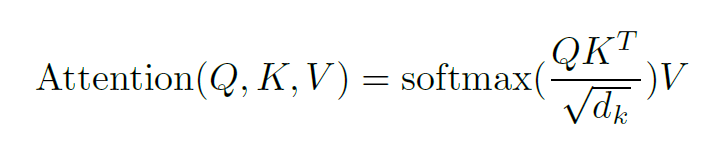

In [4]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, heads, dropout_rate):
    super().__init__()
    self.d_model = d_model
    self.heads = heads
    self.dropout = nn.Dropout(dropout_rate)
    
    self.d_k = d_model // heads
    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)
    
    self.w_o = nn.Linear(d_model, d_model)
    
  @staticmethod
  def attention(q, k, v, mask=None, dropout=None):
    d_k = q.shape[-1]
    softmax = nn.Softmax(-1)
    attention = q @ k.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
      attention = torch.where(mask == 0, attention, -1_000_000)
      
    attention = softmax(attention)
    if dropout is not None:
      attention = dropout(attention)
      
    return (attention @ v, attention)
    
  def forward(self, q, k, v, mask=None):
    query = self.w_q(q)
    key = self.w_k(k)
    value = self.w_v(v)
    
    # We will then split our three matrices into h matrices of equal dimensions
    
    query = query.view(query.shape[0], query.shape[1], self.heads, self.d_k).transpose(1, 2)
    key = key.view(key.shape[0], key.shape[1], self.heads, self.d_k).transpose(1, 2)
    value = value.view(value.shape[0], value.shape[1], self.heads, self.d_k).transpose(1, 2)
    
    X, self.attention_scores = MultiHeadAttention.attention(query, key, value, mask, self.dropout)
    
    # We then reassemble the smaller matrices
    X = X.transpose(1, 2).contiguous().view(X.shape[0], -1, self.heads * self.d_k)
    
    return self.w_o(X)

## Layer Normalization

In [45]:
class LayerNormalization(nn.Module):
  def __init__(self, epsilon=1e-5):
    super().__init__()
    self.epsilon = epsilon
    self.gamma = torch.ones(1).to(device)
    self.beta = torch.zeros(1).to(device)
    
  def forward(self, X):
    mu = X.mean(dim=-1, keepdim=True)
    sigma = X.std(dim=-1, keepdim=True)
    return self.gamma * (X - mu) / (sigma + self.epsilon) + self.beta

## Feed Forward Network

In [6]:
class FeedForward(nn.Module):
  def __init__(self, d_model, d_ff, dropout_rate=0.1):
    super().__init__()
    self.d_model = d_model
    self.d_ff = d_ff
    
    self.linear_1 = nn.Linear(d_model, d_ff)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(dropout_rate)
    self.linear_2 = nn.Linear(d_ff, d_model)
    
  def forward(self, X):
    X = self.linear_1(X)
    X = self.relu(X)
    X = self.dropout(X)
    
    return self.linear_2(X)    

## Residual Connection

In [7]:
class ResidualConnection(nn.Module):
  def __init__(self, dropout_rate=0.1):
    super().__init__()
    self.dropout = nn.Dropout(dropout_rate)
    self.norm = LayerNormalization()
    
  def forward(self, X, sublayer):
    return X + self.dropout(self.norm(sublayer(X)))

## Encoder pipeline

In [8]:
class EncoderUnit(nn.Module):
  def __init__(self, self_attention, feed_forward, dropout_rate=0.1):
    super().__init__()
    self.self_attention = self_attention
    self.feed_forward = feed_forward
    self.residual_connections = nn.ModuleList([ResidualConnection(dropout_rate) for _ in range(2)])
    
  def forward(self, X, mask):
    X = self.residual_connections[0](X, lambda x: self.self_attention(x, x, x, mask))
    X = self.residual_connections[1](X, self.feed_forward)
    return X

In [9]:
class Encoder(nn.Module):
  def __init__(self, layers):
    super().__init__()
    self.layers = layers
    self.norm = LayerNormalization()
    
  def forward(self, X, mask):
    for layer in self.layers:
      X = layer(X, mask)
      
    return self.norm(X)

## Decoder

In [10]:
class DecoderUnit(nn.Module):
  def __init__(self, self_attention, cross_attention, feed_forward, dropout_rate):
    super(DecoderUnit, self).__init__()
    self.self_attention = self_attention
    self.cross_attention = cross_attention
    self.feed_forward = feed_forward
    self.residual_connections = nn.ModuleList([ResidualConnection(dropout_rate) for _ in range(3)])
    
  def forward(self, X, encoded_X, mask_1, mask_2):
    X = self.residual_connections[0](X, lambda x: self.self_attention(x, x, x, mask_2))
    X = self.residual_connections[1](X, lambda x: self.cross_attention(x, encoded_X, encoded_X, mask_1))
    X = self.residual_connections[2](X, self.feed_forward)
    return X

In [11]:
class Decoder(nn.Module):
  def __init__(self, layers):
    super().__init__()
    self.layers = layers
    self.norm = LayerNormalization()
    
  def forward(self, X, encoded_X, mask_1, mask_2):
    for layer in self.layers:
      X = layer(X, encoded_X, mask_1, mask_2)
      
    return self.norm(X)

## Output Layer

In [12]:
class OutputLayer(nn.Module):
  def __init__(self, d_model, vocab_size):
    super().__init__()
    self.linear = nn.Linear(d_model, vocab_size)
    
  def forward(self, X):
    projection = self.linear(X)
    return torch.softmax(projection, dim=-1)

## The Transformer

In [13]:
class Transformer(nn.Module):
  def __init__(self, encoder, decoder, input_embedding, output_embedding, input_positional_encoding, output_positional_encoding, output_layer):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.input_embedding = input_embedding
    self.output_embedding = output_embedding
    self.input_positional_encoding = input_positional_encoding
    self.output_positional_encoding = output_positional_encoding
    self.output_layer = output_layer
    
    
  def encode(self, source, mask):
    source = self.input_embedding(source)
    source = self.input_positional_encoding(source)
    return self.encoder(source, mask)
  
  def decode(self, encoded_output, mask_1, target, mask_2):
    target = self.output_embedding(target)
    target = self.output_positional_encoding(target)
    return self.decoder(target, encoded_output, mask_1, mask_2)
  
  def project(self, X):
    return self.output_layer(X)

In [14]:
def build_transformer(
  source_vocab_size,
  target_vocab_size,
  source_seq_length,
  target_seq_length,
  d_model,
  N,
  heads,
  d_ff,
  dropout_rate
):
  
  source_embedding = InputEmbedding(d_model, source_vocab_size)
  target_embedding = InputEmbedding(d_model, target_vocab_size)
  
  source_pos = PositionalEncoding(d_model, source_seq_length, dropout_rate)
  target_pos = PositionalEncoding(d_model, target_seq_length, dropout_rate)
  
  encoder_units = []
  decoder_units = []
  for _ in range(N):
    self_attention = MultiHeadAttention(d_model, heads, dropout_rate)
    feed_forward = FeedForward(d_model, d_ff)
    encoder_unit = EncoderUnit(self_attention, feed_forward, dropout_rate)
    encoder_units.append(encoder_unit)
  
  for _ in range(N):
    self_attention = MultiHeadAttention(d_model, heads, dropout_rate)
    cross_attention = MultiHeadAttention(d_model, heads, dropout_rate)
    feed_forward = FeedForward(d_model, d_ff)
    decoder_unit = DecoderUnit(self_attention, cross_attention, feed_forward, dropout_rate)
    decoder_units.append(decoder_unit)
    
  encoder = Encoder(nn.ModuleList(encoder_units))
  decoder = Decoder(nn.ModuleList(decoder_units))
  
  output_layer = OutputLayer(d_model, target_vocab_size)
  
  transformer = Transformer(encoder, decoder, source_embedding, target_embedding, source_pos, target_pos, output_layer)
  
  for param in transformer.parameters():
    if param.dim() > 1:
      nn.init.uniform_(param)
      
  return transformer

## The dataset

In [15]:
ds = load_dataset("PaulineSanchez/Translation_words_and_sentences_english_french")

README.md:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

(…)-00000-of-00001-3d14582ea46e1b17.parquet:   0%|          | 0.00/6.43M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/175466 [00:00<?, ? examples/s]

In [16]:
ds['train'] = ds['train'].rename_columns({"English words/sentences": "en", "French words/sentences": "fr"})

## Preprocessing: tokenization

In [17]:
tokenizer_src = AutoTokenizer.from_pretrained("t5-small")
tokenizer_tgt = AutoTokenizer.from_pretrained("t5-small")

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

In [18]:
def preprocess_data(examples):
  inputs = examples["en"]
  targets = examples["fr"]
  model_inputs = tokenizer_src(
    text=inputs, 
    max_length=128, 
    truncation=True, 
  )
  
  with tokenizer_src.as_target_tokenizer():
    labels = tokenizer_tgt(
      text=targets, 
      max_length=128, 
      truncation=True, 
    )
    
  model_inputs["labels"] = labels["input_ids"]
  return model_inputs

tokenized_ds = ds.map(preprocess_data, batched=False, remove_columns=list(ds["train"].column_names))

Map:   0%|          | 0/175466 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [19]:
tokenized_ds = tokenized_ds['train'].train_test_split(test_size=0.3, shuffle=True, seed=42)

In [90]:
train = tokenized_ds['train'].select(range(10000))
test = tokenized_ds['test'].select(range(3000))

In [74]:
class TranslationDataset(Dataset):
  def __init__(self, tokenized_ds):
    self.dataset = tokenized_ds
    
  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    item = {key: torch.tensor(val) for key, val in self.dataset[idx].items()}
    return item

In [91]:
train_dataset = TranslationDataset(train)
test_dataset = TranslationDataset(test)

## Collator function to deal with dynamic batch sizes

In [23]:
def collate_fn(batch):
  input_ids = [item["input_ids"] for item in batch]
  attention_mask = [item["attention_mask"] for item in batch]
  labels = [item["labels"] for item in batch]

  input_ids = rnn_utils.pad_sequence(
    input_ids, batch_first=True, padding_value=tokenizer_src.pad_token_id
  )
  attention_mask = rnn_utils.pad_sequence(
    attention_mask, batch_first=True, padding_value=0
  )
  labels = rnn_utils.pad_sequence(
    labels, batch_first=True, padding_value=tokenizer_tgt.pad_token_id
  )

  return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

In [92]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=64, collate_fn=collate_fn)

In [85]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [93]:
model = build_transformer(
  source_vocab_size=tokenizer_src.vocab_size,
  target_vocab_size=tokenizer_tgt.vocab_size,
  source_seq_length=128,
  target_seq_length=128,
  d_model=512,
  N=6,
  heads=8,
  d_ff=2048,
  dropout_rate=0.1
).to(device)

## Training loop

In [94]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer_tgt.pad_token_id)

In [95]:
def train_epoch(model, loader):

  model.train()
  total_loss = 0
  for batch in tqdm(loader):
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch.get("attention_mask", None).to(device)
    labels = batch["labels"].to(device)

    src_mask = None
    if attention_mask is not None:
      src_mask = (attention_mask == 0).unsqueeze(1).unsqueeze(2).to(device)

    tgt_input = labels[:, :-1]
    tgt_mask = (tgt_input != tokenizer_tgt.pad_token_id).unsqueeze(1).unsqueeze(2)
    seq_len = tgt_input.size(1)
    subsequent_mask = torch.triu(torch.ones((1, seq_len, seq_len), device=device), diagonal=1).bool()
    tgt_mask = tgt_mask & ~subsequent_mask

    encoded = model.encode(input_ids, src_mask)
    decoded = model.decode(encoded, src_mask, tgt_input, tgt_mask)
    logits = model.project(decoded)

    loss = criterion(logits.reshape(-1, logits.size(-1)), labels[:, 1:].reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  return total_loss / len(loader)

In [96]:
sum([p.numel() for p in model.parameters()])

93445476

In [97]:
for epoch in range(10):
    avg_loss = train_epoch(model, train_loader)
    print(f"Epoch {epoch + 1} | Loss: {avg_loss:.4f}")

100%|██████████| 157/157 [00:24<00:00,  6.30it/s]


Epoch 1 | Loss: 10.2811


100%|██████████| 157/157 [00:24<00:00,  6.39it/s]


Epoch 2 | Loss: 10.2537


100%|██████████| 157/157 [00:24<00:00,  6.50it/s]


...

Epoch 8 | Loss: 10.2538


100%|██████████| 157/157 [00:24<00:00,  6.40it/s]


Epoch 9 | Loss: 10.2538


100%|██████████| 157/157 [00:24<00:00,  6.37it/s]

Epoch 10 | Loss: 10.2536
